# Thuật toán Decision Tree 

### Tải dữ liệu và Thư viện

In [34]:
import sys
import os
import joblib
from pathlib import Path

project_root = Path.cwd().parent  
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

try:
    if Path(os.getcwd()).name == 'notebooks':
        os.chdir('..')
        print(f"CWD đã chuyển sang: {os.getcwd()}")
except Exception as e:
    print(f"Lỗi chuyển CWD: {e}")
    
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from src.models import get_model

In [35]:
X_train = np.load('/Users/binhminh/Documents/Intro ML code /Data/X_train.npy')
X_test = np.load('/Users/binhminh/Documents/Intro ML code /Data/X_test.npy')
y_train = np.load('/Users/binhminh/Documents/Intro ML code /Data/y_train.npy')
y_test = np.load('/Users/binhminh/Documents/Intro ML code /Data/y_test.npy')

### Huấn luyện Mô hình và Tinh chỉnh Tham số 

In [40]:
dt_classifier = DecisionTreeClassifier(random_state=42)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None], 
    'splitter': ['best', 'random']           
}

grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, 
                           scoring='accuracy', cv=5, verbose=1, n_jobs=-1)

print("Đang tìm kiếm tham số tối ưu cho Decision Tree...")
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("\n" + "="*40)
print("Best Parameters:", grid_search.best_params_)
print(f"Best Score (CV): {grid_search.best_score_:.4f}")
print("="*40)

Đang tìm kiếm tham số tối ưu cho Decision Tree...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'random'}
Best Score (CV): 0.9516


### Đánh giá Hiệu năng Mô hình

In [41]:
best_model_dt = grid_search.best_estimator_

model_name = "Decision Tree Classifier"
y_pred_dt = best_model_dt.predict(X_test)

acc = accuracy_score(y_test, y_pred_dt)
print(f"\nĐộ chính xác (Accuracy) của {model_name}: {acc*100:.2f}%")
print("-" * 30)
print("Báo cáo chi tiết (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred_dt))
print("-" * 30)
print(f'F1_Score: {classification_report(y_test, y_pred_dt, output_dict=True)["weighted avg"]["f1-score"]:.4f}')
print(f'Accuracy: {classification_report(y_test, y_pred_dt, output_dict=True)["accuracy"]:.4f}')


Độ chính xác (Accuracy) của Decision Tree Classifier: 94.74%
------------------------------
Báo cáo chi tiết (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        72
           1       0.95      0.90      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

------------------------------
F1_Score: 0.9471
Accuracy: 0.9474


### Trực quan hóa kết quả 

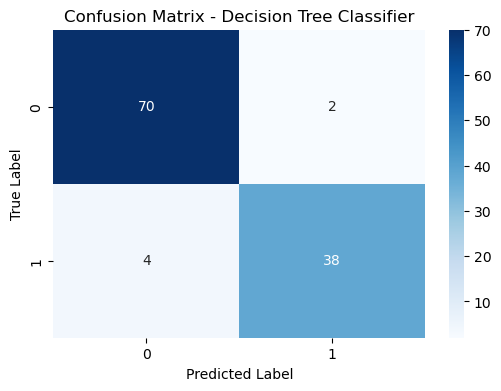

Exception ignored in: <function ResourceTracker.__del__ at 0x104e6de40>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104b21e40>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1023f5e40>
Traceback (most recent call last

In [42]:
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Lưu trữ mô hình

In [39]:
os.makedirs('models', exist_ok=True)
file_path_ab = "models/decision_tree.pkl"
joblib.dump(best_model_dt, file_path_ab)

print(f"Đã lưu mô hình Decision Tree tại: {file_path_ab}")

Đã lưu mô hình Decision Tree tại: models/decision_tree.pkl


Exception ignored in: <function ResourceTracker.__del__ at 0x104b85e40>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10581de40>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104691e40>
Traceback (most recent call last